# Klädklassificering med Fashion MNIST: en fördjupning i optimerare och learning rate

---

I det här projektet bygger vi en klassificeringsmodell som ska känna igen olika typer av klädesplagg från Fashion MNIST-datasetet. Fokus ligger inte bara på att få modellen att prestera bra, utan på att undersöka hur olika val påverkar resultatet. Vår fördjupning handlar om optimerare och learning rate, där vi jämför flera varianter för att analysera hur de påverkar modellens träning, accuracy, loss och risk för over- eller underfitting. 

Projektets medlemmar är: 

- Alma
- Jack
- Josefin
- Malin
- Shara
- Vera

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1 Förstå datan

### Fashion MNIST

Datan som användas i detta projekt är Fashion MNIST, ett inbyggt dataset i Keras som innehåller gråskalebilder av olika klädesplagg. 

Datasetet är färdigt uppdelat i träningsdata och testdata. 

- Träningsdata används för att lära modellen
- Testdata används för att utvärdera modellen efter träning

https://keras.io/api/datasets/fashion_mnist/

In [4]:
# Hämtar Fashion MNIST-datasetet från Keras
fashion_mnist = keras.datasets.fashion_mnist

# Laddar in datasetet. X innehåller bilderna och y innehåller etiketterna/klasserna
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

### Datans struktur

Undersöker datans form för att förstå hur många bilder vi har och hur de är strukturerade.

Varje bild är 28x28 pixlar och lagras som en matris med siffror.

In [5]:
# Skriver ut form (shape) på tränings- och testdata för att förstå datans storlek
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)

print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


### Klassnamn

Eftersom etiketter (labels) i datan är siffror (0–9) använder vi en lista med klassnamn för att göra resultaten mer begripliga.

In [6]:
# Lista med klassnamn som motsvarar siffrorna (0–9) i datasetet
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# Skriver ut varje label och motsvarande klassnamn
for i, name in enumerate(class_names):
    print(i, name)

0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot


### Visualisering av en bild

Visar en enskild bild från datasetet för att förstå hur datan ser ut och hur den kopplas till rätt klass.

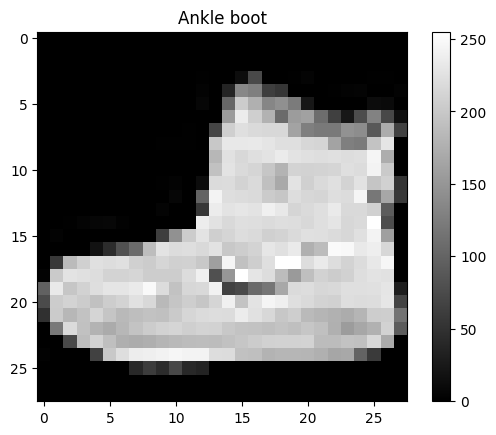

In [7]:
# Visar första bilden i träningsdatan
plt.imshow(X_train[0], cmap='gray')

# Lägger till titel med rätt klassnamn för bilden
plt.title(class_names[y_train[0]])

# Visar färgskalan (pixelvärden)
plt.colorbar()
plt.show()

### Flera exempelbilder

Visar flera bilder samtidigt för att få en bättre känsla för variationen i datasetet och hur olika klasser ser ut.

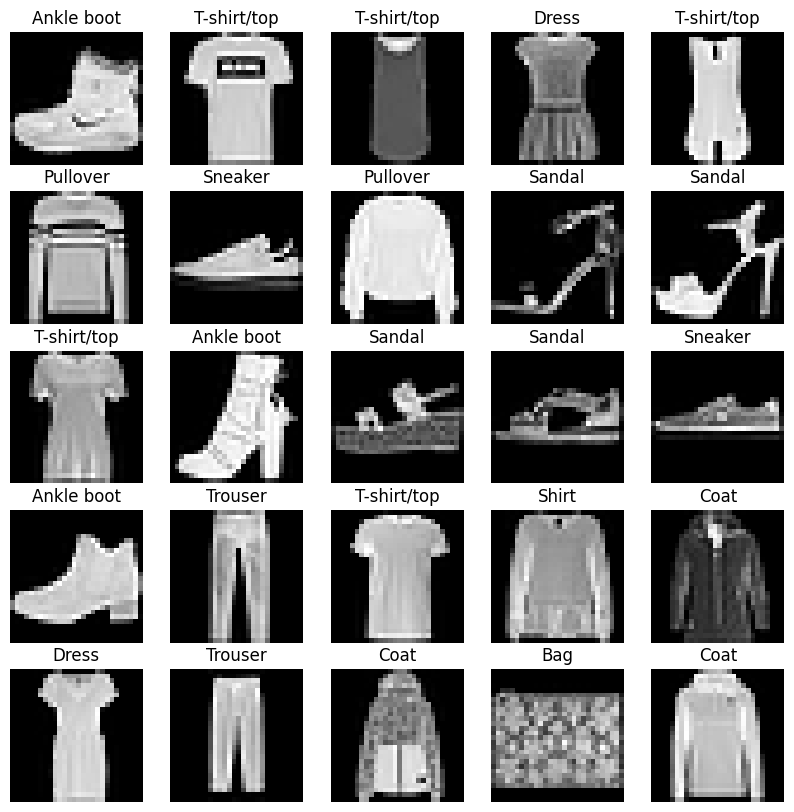

In [8]:
# Visar de första 25 bilderna i träningsdatan i ett 5x5 rutnät,
# tillsammans med respektive klassnamn för att enkelt kunna koppla bild till kategori
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

### Klassfördelning

Vi räknar antalet bilder per klass för att undersöka om datasetet är balanserat. Om alla klasser har ungefär lika många bilder behöver vi inte ta särskild hänsyn till klassobalans vid träning och utvärdering av modellen.

In [9]:
# Räknar hur många bilder som finns i varje klass i träningsdatan
unique, counts = np.unique(y_train, return_counts=True)

# Skriver ut antal bilder per klass för att kontrollera datans fördelning
for label, count in zip(unique, counts):
    print(class_names[label], ':', count)

T-shirt/top : 6000
Trouser : 6000
Pullover : 6000
Dress : 6000
Coat : 6000
Sandal : 6000
Shirt : 6000
Sneaker : 6000
Bag : 6000
Ankle boot : 6000


## 2 Dataförberedelse

### Valideringsset

Vi skapar ett valideringsset från träningsdatan för att kunna följa hur modellen presterar på data den inte tränas på. 

På så sätt kan vi upptäcka om modellen börjar överanpassa sig till träningsdatan. 

Vi använder 20 % av träningsdatan som valideringsdata eftersom det ger tillräckligt mycket data för validering samtidigt som majoriteten fortfarande används för träning.

In [10]:
# Skapa valideringsset
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# Kontrollera att det stämmer
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (48000, 28, 28)
X_val: (12000, 28, 28)
y_train: (48000,)
y_val: (12000,)


### Lägga till kanaldimension

Fashion MNIST-bilderna lagras som 2D-arrayer med formen (28, 28) och saknar därför en explicit kanaldimension.

CNN-lager förväntar sig däremot bilder i formatet (höjd, bredd, kanaler) så vi lägger till en extra dimension för färgkanalen.

Bilderna får då formen (28, 28, 1) där 1 betyder färgkanal (1 = gråskala, 3 = RGB/färgbild)

In [11]:
# Lägga till kanaldimension till X_train
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train shape efter kanal-dimension:", X_train.shape)
print("X_val shape efter kanal-dimension:", X_val.shape)
print("X_test shape efter kanal-dimension:", X_test.shape)

X_train shape efter kanal-dimension: (48000, 28, 28, 1)
X_val shape efter kanal-dimension: (12000, 28, 28, 1)
X_test shape efter kanal-dimension: (10000, 28, 28, 1)


### Normalisering av pixelvärden

Bildernas pixelvärden ligger från början mellan 0 och 255. 

Genom att dividera värdena med 255 normaliseras datan till intervallet 0-1, vilket ofta gör träningen mer stabil och effektiv för neurala nätverk.

In [12]:
# Normaliserar pixelvärden från 0-255 till 0-1
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

# Kontrollerar att normaliseringen fungerade
print("X_train min/max:", X_train.min(), X_train.max())
print("X_val min/max:", X_val.min(), X_val.max())
print("X_test min/max:", X_test_norm.min(), X_test_norm.max())
print("X_train shape:", X_train.shape)

X_train min/max: 0.0 1.0
X_val min/max: 0.0 1.0
X_test min/max: 0.0 1.0
X_train shape: (48000, 28, 28, 1)


## 3 Bygga en första modell

Vi valde att börja med en enkel CNN-modell som basmodell eftersom datasetet består av bilddata. 

Convolution-lagret används för att hitta mönster i bilderna, medan MaxPooling minskar datamängden och gör modellen mer effektiv.

Dense-lagren används sedan för att klassificera bilden till en av de 10 klasserna. 

In [13]:
# Basmodell

baseline_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

## 4 Träna modellen

Föregående steg definierar endast modellen struktur. Inställningar för optimizer, learning rate och batch size anges i funktionen model_compile_and_fit, där modellen kompileras och tränas.

På så sätt kan vi återanvända samma modellstruktur men enkelt jämföra olika träningsinställningar. 

Som basinställningar valde vi Adam som optimizer, learning rate 0,001, batch size 32 och 20 epoker. 

Dessa värden används som en stabil utgångspunkt innan vi testar andra varianter på optimizer och learning rate.

Adam är en vanligt använd optimizer som ofta fungerar bra som standardval. Learning rate 0,001 är ett vanligt startvärde för Adam, medan batch size 32 ger en rimlig balans mellan stabil träning och effektivitet. 

Vi valde 20 epoker för att modellen skulle hinna lära sig mönster i datan, samtidigt som vi kunde följa om den började visa tecken på overfitting. Vi använder även Early Stopping för att avbryta träningen om valideringsförslusten (val_loss) inte förbättras efter 3 epoker. Detta minskar risken för overfitting och gör att modellen återgår till de bästa vikterna från träningen. 

Modellen kompileras med loss-funktionen sparse_categorical_crossentropy eftersom uppgiften är en flerkategoriklassificering där varje bild tillhör en av 10 klasser. Etiketterna är heltal, 0-9, vilket gör att vi kan anvnda "sparse"-varianten utan att först omvandla etiketterna med one-hot encoding.

https://keras.io/api/optimizers/adam/

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8546 - loss: 0.4088 - val_accuracy: 0.8845 - val_loss: 0.3190
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9013 - loss: 0.2745 - val_accuracy: 0.8961 - val_loss: 0.2853
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9173 - loss: 0.2269 - val_accuracy: 0.9063 - val_loss: 0.2667
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9316 - loss: 0.1885 - val_accuracy: 0.9078 - val_loss: 0.2641
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9438 - loss: 0.1570 - val_accuracy: 0.9084 - val_loss: 0.2745
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9539 - loss: 0.1297 - val_accuracy: 0.9057 - val_loss: 0.2938
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9617 - loss: 0.1086 - val_accuracy: 0.9063 - val_loss: 0.3134

Resultat för Basmodell:
Antal epoker:        7
Train accuracy:      0.9438
Train loss:   

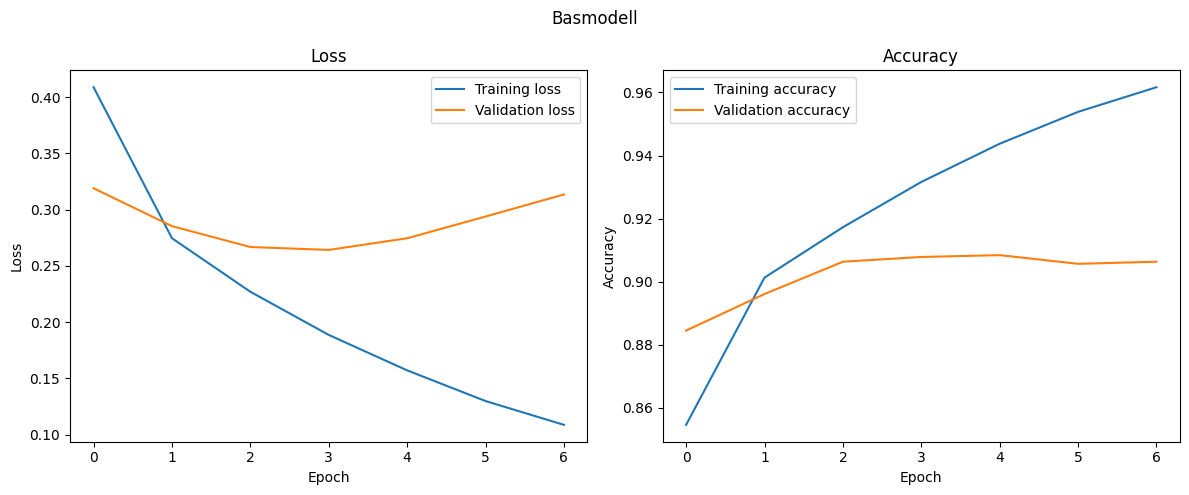

     name  train_accuracy  train_loss  validation_accuracy  validation_loss  epochs_trained  learning_rate  training_time
Basmodell         0.94375    0.157032             0.908417         0.274462               7          0.001      22.342468


In [14]:
# Importerar egna hjälpfunktioner för träning och visualisering av resultat
from utils_final import model_compile_and_fit
from utils_final import plot_history

# Skapar en lista för att spara resultatet i
results = []

# Kompilerar och tränar basmodellen
model_bas, h_bas, r_bas = model_compile_and_fit(baseline_model, X_train, y_train, X_val, y_val, name="Basmodell")
results.append(r_bas)

print(pd.DataFrame(results).to_string(index=False))

### Analys av basmodell

Resultatet visar att basmodellen lär sig snabbt på träningsdatan, eftersom training_loss minskar och training_accuracy ökar tydligt. 

Valideringsresultatet förbättras i början, men planar sedan ut runt 90 % accuracy. 

Efter några epoker börjar validation_loss öka samtidigt som training_loss fortsätter minska, vilket tyder på overfitting. 

Early Stopping avbryter träningen efter 7 epoker, eftersom modellen inte längre förbättras på valideringsdatan.

Resulatet är 94 % training_accuracy och 90 % validation_accuracy. 

## 5 Testa och förbättra modellen

Basmodellen utökas med ytterligare ett Conv2D-block för att den ska kunna lära sig mer komplexa bildmönster och förbättra klassificeringen. 

MaxPooling minskar samtidigt bildens dimensioner och hjälper modellen fokusera på viktiga features.

In [ ]:
# Förbättrad modell med ett till Conv2D-block
improved_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu",),
    layers.Dense(10, activation="softmax")
])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8483 - loss: 0.4204 - val_accuracy: 0.8847 - val_loss: 0.3165
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9006 - loss: 0.2720 - val_accuracy: 0.9066 - val_loss: 0.2638
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9177 - loss: 0.2240 - val_accuracy: 0.9117 - val_loss: 0.2511
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9308 - loss: 0.1873 - val_accuracy: 0.9149 - val_loss: 0.2419
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9428 - loss: 0.1567 - val_accuracy: 0.9147 - val_loss: 0.2536
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9526 - loss: 0.1279 - val_accuracy: 0.9162 - val_loss: 0.2679
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9612 - loss: 0.1054 - val_accuracy: 0.9161 - val_loss: 0.2855

Resultat för Förbättrad modell:
Antal epoker:        7
Train accuracy:      0.9526
Train 

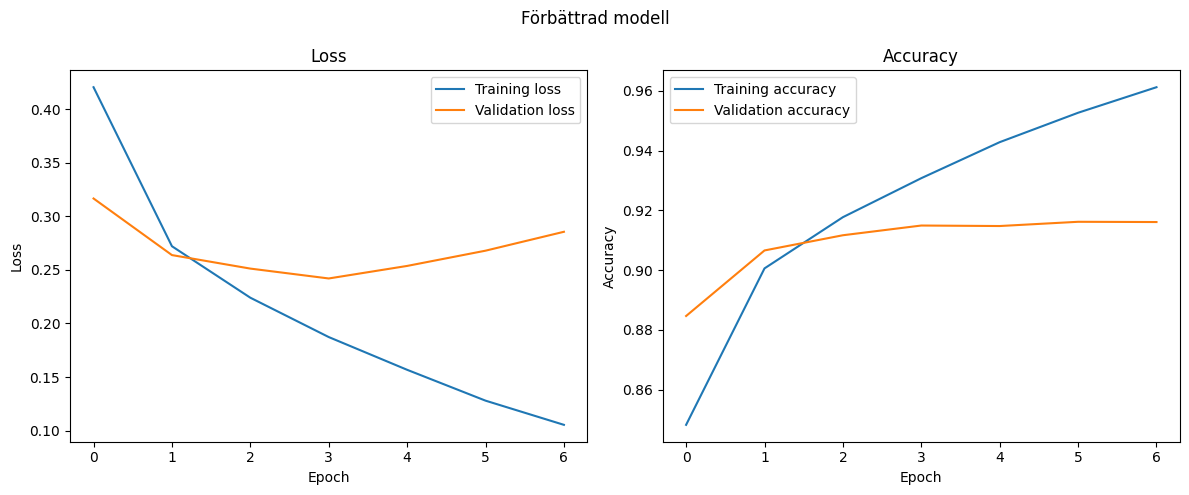

             name  train_accuracy  train_loss  validation_accuracy  validation_loss  epochs_trained  learning_rate  training_time
        Basmodell        0.943750    0.157032             0.908417         0.274462               7          0.001      22.342468
Förbättrad modell        0.952625    0.127941             0.916167         0.267856               7          0.001      31.891955


In [16]:
# Compilerar och tränar förbättrad modell
model_imp, h_imp, r_imp = model_compile_and_fit(improved_model, X_train, y_train, X_val, y_val, name="Förbättrad modell")
results.extend([r_imp])

print(pd.DataFrame(results).to_string(index=False))

### Analys av förbättrad modell

Det extra Conv2D-lagret ger en något bättre accuracy på validationdatan men kurvorna uppvisar samma mönster av överanpassning som i basmodellen.  

För att minska överanpassningen testades att lägga till dropout.

In [17]:
# Ytterligare förbättrad modell med dropout
improved_model2 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu",),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8307 - loss: 0.4710 - val_accuracy: 0.8841 - val_loss: 0.3077
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8865 - loss: 0.3110 - val_accuracy: 0.8909 - val_loss: 0.2917
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9040 - loss: 0.2607 - val_accuracy: 0.9123 - val_loss: 0.2433
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9145 - loss: 0.2290 - val_accuracy: 0.9072 - val_loss: 0.2611
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9239 - loss: 0.2030 - val_accuracy: 0.9158 - val_loss: 0.2405
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9319 - loss: 0.1822 - val_accuracy: 0.9172 - val_loss: 0.2368
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9390 - loss: 0.1617 - val_accuracy: 0.9231 - val_loss: 0.2344
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9448 - loss: 0.1458 - 

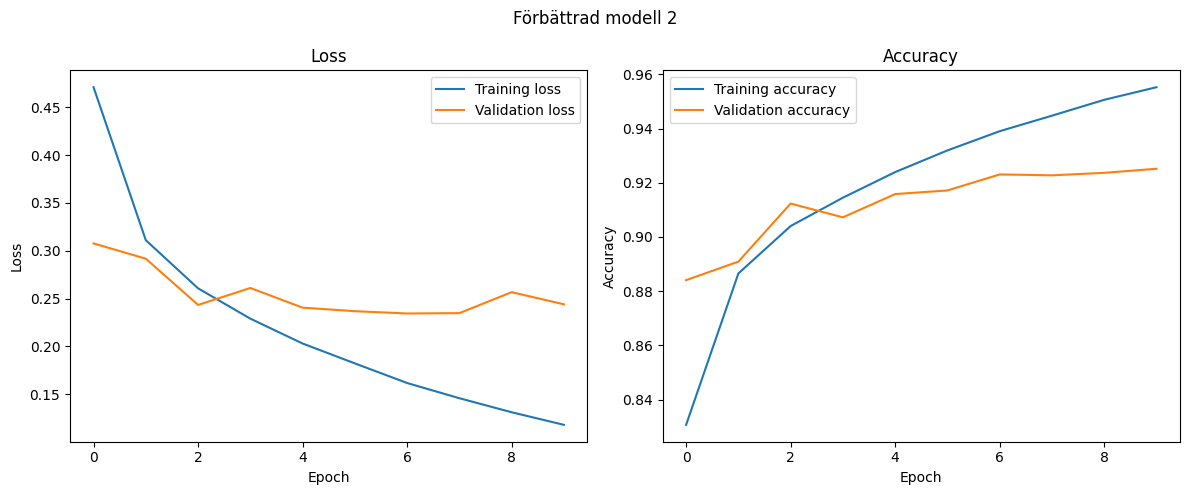

               name  train_accuracy  train_loss  validation_accuracy  validation_loss  epochs_trained  learning_rate  training_time
          Basmodell        0.943750    0.157032             0.908417         0.274462               7          0.001      22.342468
  Förbättrad modell        0.952625    0.127941             0.916167         0.267856               7          0.001      31.891955
Förbättrad modell 2        0.955250    0.117969             0.925167         0.244005              10          0.001      48.816590


In [18]:
# Compilerar och tränar förbättrad modell 2

model_imp2, h_imp2, r_imp2 = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="Förbättrad modell 2")
results.append(r_imp2)

print(pd.DataFrame(results).to_string(index=False))

### Analys av förbättrad modell 2

Med dropout blir tränings-accuracy något lägre jämfört med tidigare modeller, men skillnaden mellan tränings- och valideringsdata minskar. 

Valideringsdatan får lägre loss, från 0.274 till 0.244, vilket tyder på bättre generalisering. 

Tränings- och valideringskurvorna följer varandra bättre, vilket indikerar att modellen överanpassar mindre än de tidigare modellerna. 

## 6 Fördjupning i fokusområde optimerare och inlärningshastighet

I denna del undersöks hur valet av optimerare och inlärningshastighet påverkar modellens prestanda. 

Tre olika optimerare testas: 

- SGD
- RMSprop
- Adam

Varje optimerare körs med tre olika learning rates: 

- 0.0001
- 0.001
- 0.01

Syftet är att jämföra hur snabbt modellerna lär sig, hur stabil träningen är och vilken kombination som ger bäst resultat på valideringsdatan.

### Experiment SGD med LR 0,0001, 0,001 och 0,01

SGD testas för att undersöka hur en enklare optimerare påverkas av olika learning rates.

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1117 - loss: 2.2939 - val_accuracy: 0.1161 - val_loss: 2.2782
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1623 - loss: 2.2649 - val_accuracy: 0.1917 - val_loss: 2.2487
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2240 - loss: 2.2336 - val_accuracy: 0.2846 - val_loss: 2.2130
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2872 - loss: 2.1922 - val_accuracy: 0.3810 - val_loss: 2.1642
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3429 - loss: 2.1352 - val_accuracy: 0.4789 - val_loss: 2.0934
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4006 - loss: 2.0518 - val_accuracy: 0.5227 - val_loss: 1.9880
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4479 - loss: 1.9269 - val_accuracy: 0.5467 - val_loss: 1.8339
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4746 - loss: 1.7625 - 

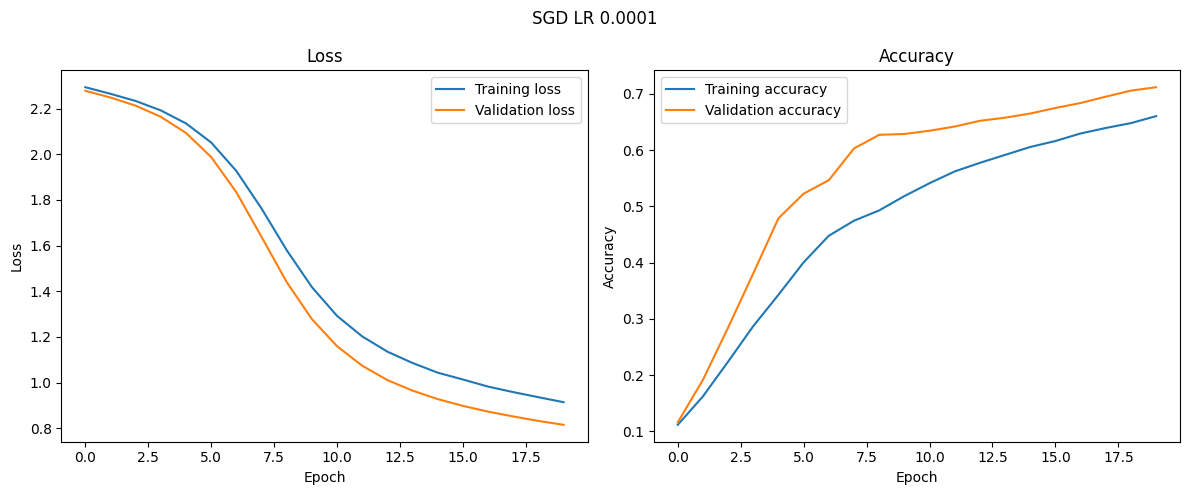

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3407 - loss: 1.9885 - val_accuracy: 0.6294 - val_loss: 1.2831
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6061 - loss: 1.0660 - val_accuracy: 0.7059 - val_loss: 0.8285
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6892 - loss: 0.8441 - val_accuracy: 0.7450 - val_loss: 0.7217
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7316 - loss: 0.7502 - val_accuracy: 0.7648 - val_loss: 0.6618
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7518 - loss: 0.6939 - val_accuracy: 0.7793 - val_loss: 0.6221
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7682 - loss: 0.6528 - val_accuracy: 0.7912 - val_loss: 0.5877
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7796 - loss: 0.6189 - val_accuracy: 0.7983 - val_loss: 0.5699
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7894 - loss: 0.5957 - 

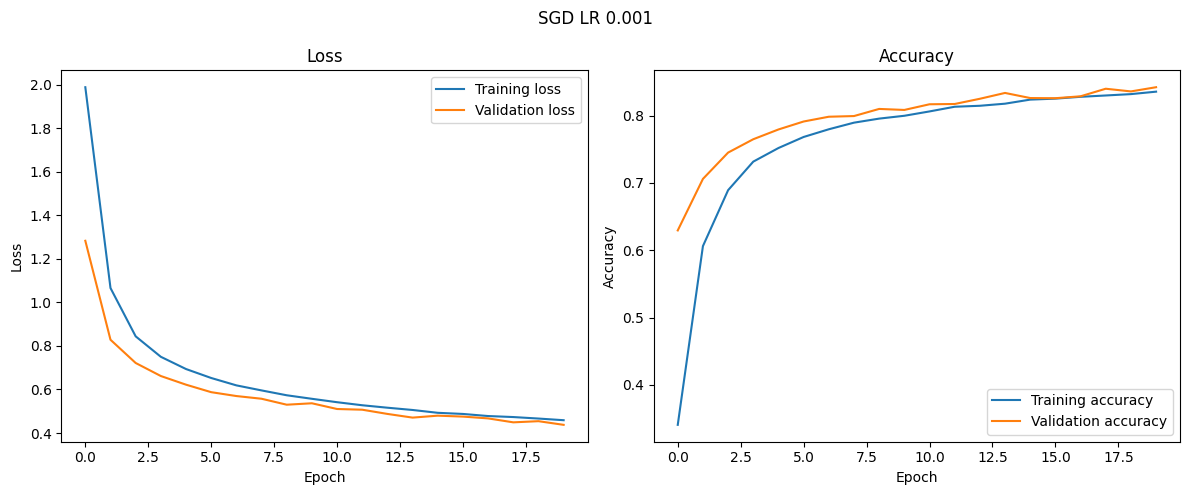

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6627 - loss: 0.9231 - val_accuracy: 0.7747 - val_loss: 0.6005
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7798 - loss: 0.5895 - val_accuracy: 0.7827 - val_loss: 0.5486
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8133 - loss: 0.5063 - val_accuracy: 0.8203 - val_loss: 0.4741
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8317 - loss: 0.4603 - val_accuracy: 0.8421 - val_loss: 0.4309
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8450 - loss: 0.4268 - val_accuracy: 0.8550 - val_loss: 0.3948
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8529 - loss: 0.4064 - val_accuracy: 0.8580 - val_loss: 0.3858
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8599 - loss: 0.3863 - val_accuracy: 0.8582 - val_loss: 0.3862
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8648 - loss: 0.3725 - 

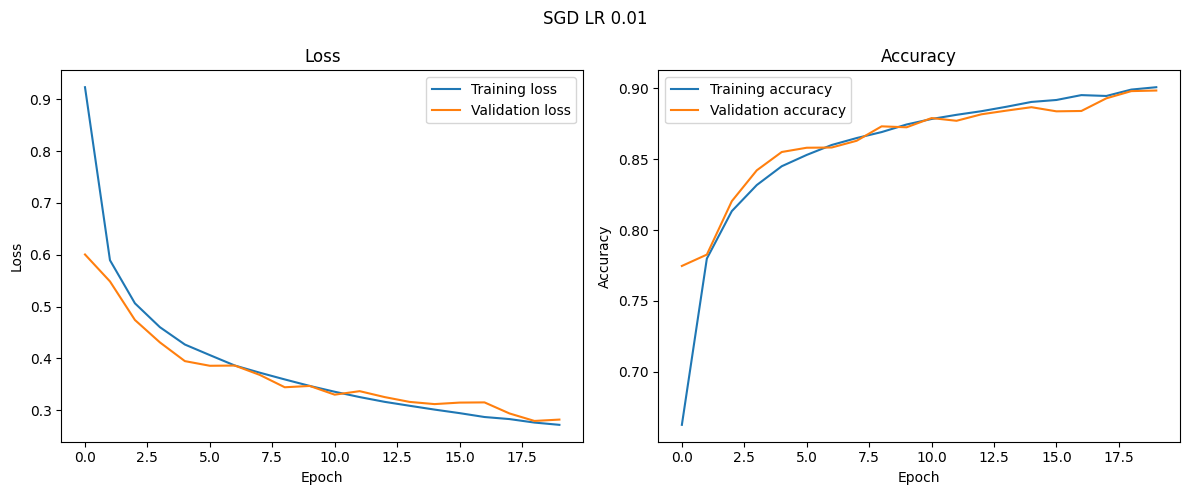

               name  train_accuracy  train_loss  validation_accuracy  validation_loss  epochs_trained  learning_rate  training_time
          Basmodell        0.943750    0.157032             0.908417         0.274462               7         0.0010      22.342468
  Förbättrad modell        0.952625    0.127941             0.916167         0.267856               7         0.0010      31.891955
Förbättrad modell 2        0.955250    0.117969             0.925167         0.244005              10         0.0010      48.816590
      SGD LR 0.0001        0.660563    0.914238             0.712000         0.815127              20         0.0001      88.854151
       SGD LR 0.001        0.835479    0.458895             0.842083         0.437605              20         0.0010      88.781878
        SGD LR 0.01        0.900667    0.271908             0.898333         0.282039              20         0.0100      88.964514


In [19]:
# Experiment med SGD och olika inlärningshastigheter
model_sgd_low, h_sgd_low, r_sgd_low = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="SGD LR 0.0001", optimizer="sgd", learning_rate=0.0001)
model_sgd, h_sgd, r_sgd = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="SGD LR 0.001", optimizer="sgd", learning_rate=0.001)
model_sgd_high, h_sgd_high, r_sgd_high = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="SGD LR 0.01", optimizer="sgd", learning_rate=0.01)
results.extend([r_sgd_low, r_sgd, r_sgd_high])

print(pd.DataFrame(results).to_string(index=False))

### Analys av SGD-experimentet

SGD påverkades tydligt av valet av learning rate. 

Med learning rate 0.0001 lärde sig modellen mycket långsamt och nådde förhållande vis låg accuracy även efter många epoker. 

Learning rate 0.001 gav bättre resultat och stabil träning, men modellen konvergerade (började stabiliseras och plana ut) fortfarande relativt långsamt. 

Bäst resultat uppnåddes med learning rate 0.01, där både tränings- och valideringsaccuracyn blev högst samtidigt som loss minskade snabbast. 

Resultatet visar att SGD är känslig för valet av learning rate och kräver en tillräckligt hög inlärningshastighet för att träningen ska bli effektiv. 

Early stopping aktiverades inte i något av experimenten, vilket indikerar att modellerna fortfarande lärde sig under hela träningsprocessen och inte visade tydliga tecken på overfitting. 

Att tränings- och valideringskurvorna följer varandra relativt väl i alla tre experiment är också ett tecken på begränsad överanpassning.

### Experiment RMSprop med LR 0,0001, 0,001 och 0,01

RMSprop anpassar learning rate dynamiskt under träningen och kan därför ge snabbare konvergens.

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7322 - loss: 0.7579 - val_accuracy: 0.8216 - val_loss: 0.4828
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8313 - loss: 0.4727 - val_accuracy: 0.8431 - val_loss: 0.4296
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8549 - loss: 0.4056 - val_accuracy: 0.8581 - val_loss: 0.3876
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8678 - loss: 0.3721 - val_accuracy: 0.8673 - val_loss: 0.3646
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8782 - loss: 0.3438 - val_accuracy: 0.8781 - val_loss: 0.3330
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8838 - loss: 0.3285 - val_accuracy: 0.8768 - val_loss: 0.3333
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8881 - loss: 0.3122 - val_accuracy: 0.8817 - val_loss: 0.3250
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8928 - loss: 0.3006 - 

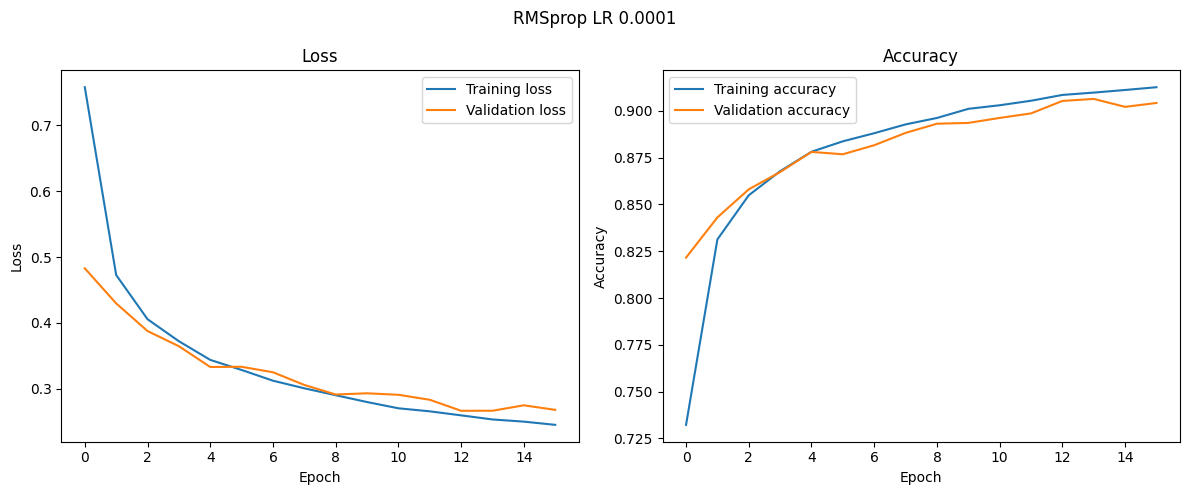

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8298 - loss: 0.4722 - val_accuracy: 0.8759 - val_loss: 0.3281
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8917 - loss: 0.3032 - val_accuracy: 0.8952 - val_loss: 0.2881
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9078 - loss: 0.2596 - val_accuracy: 0.8990 - val_loss: 0.2741
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9156 - loss: 0.2371 - val_accuracy: 0.9047 - val_loss: 0.2719
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9219 - loss: 0.2221 - val_accuracy: 0.9064 - val_loss: 0.2602
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9266 - loss: 0.2120 - val_accuracy: 0.9144 - val_loss: 0.2500
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9271 - loss: 0.2089 - val_accuracy: 0.9105 - val_loss: 0.2657
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9304 - loss: 0.2011 - 

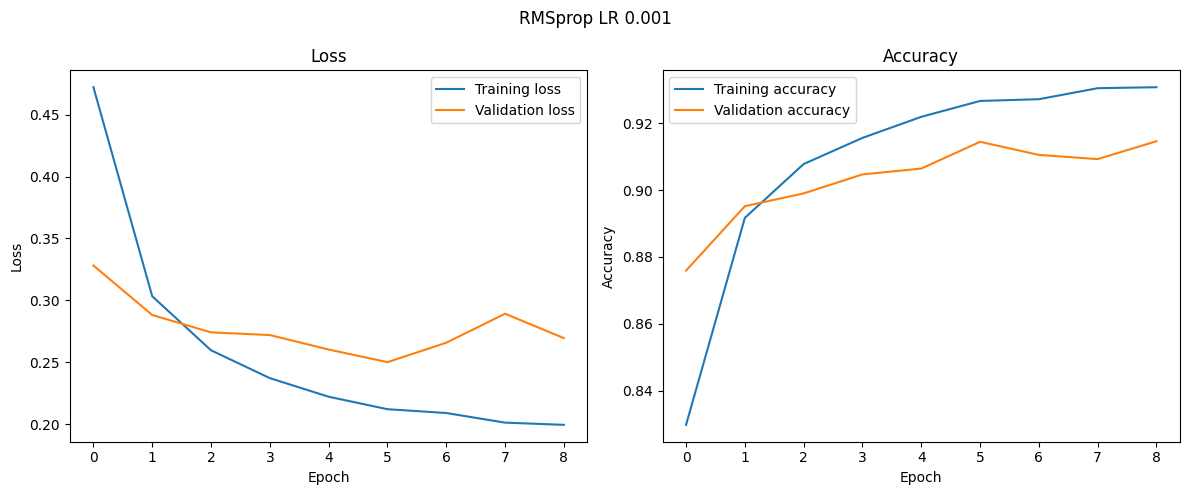

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8130 - loss: 0.5358 - val_accuracy: 0.8298 - val_loss: 0.4517
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8470 - loss: 0.4441 - val_accuracy: 0.8644 - val_loss: 0.3799
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8477 - loss: 0.4397 - val_accuracy: 0.8478 - val_loss: 0.4150
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8485 - loss: 0.4424 - val_accuracy: 0.8542 - val_loss: 0.4174
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8444 - loss: 0.4530 - val_accuracy: 0.8579 - val_loss: 0.4317

Resultat för RMSprop LR 0.01:
Antal epoker:        5
Train accuracy:      0.8470
Train loss:          0.4441
Validation accuracy: 0.8644
Validation loss:     0.3799
Träningstid:         21.27 sekunder


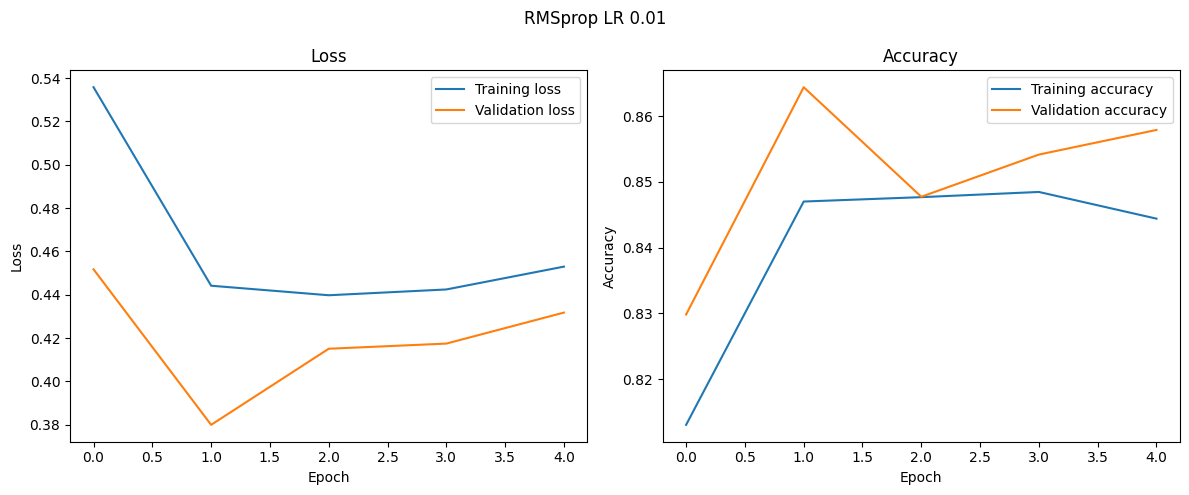

               name  train_accuracy  train_loss  validation_accuracy  validation_loss  epochs_trained  learning_rate  training_time
          Basmodell        0.943750    0.157032             0.908417         0.274462               7         0.0010      22.342468
  Förbättrad modell        0.952625    0.127941             0.916167         0.267856               7         0.0010      31.891955
Förbättrad modell 2        0.955250    0.117969             0.925167         0.244005              10         0.0010      48.816590
      SGD LR 0.0001        0.660563    0.914238             0.712000         0.815127              20         0.0001      88.854151
       SGD LR 0.001        0.835479    0.458895             0.842083         0.437605              20         0.0010      88.781878
        SGD LR 0.01        0.900667    0.271908             0.898333         0.282039              20         0.0100      88.964514
  RMSprop LR 0.0001        0.909792    0.253348             0.906417        

In [20]:
# Experiment med RMSprop och olika inlärningshastigheter
model_rms_low, h_rms_low, r_rms_low = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="RMSprop LR 0.0001", optimizer="rmsprop", learning_rate=0.0001)
model_rms, h_rms, r_rms = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="RMSprop LR 0.001", optimizer="rmsprop", learning_rate=0.001)
model_rms_high, h_rms_high, r_rms_high = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="RMSprop LR 0.01", optimizer="rmsprop", learning_rate=0.01)
results.extend([r_rms_low, r_rms, r_rms_high])

print(pd.DataFrame(results).to_string(index=False))

### Analys av RMSprop-experimentet

RMSprop med learning rate 0.0001 gav de mest stabila träningskurvorna och ett litet gap mellan tränings- och valideringsdata, vilket tyder på god generalisering. 

Learning rate 0.001 nådde något högre accuracy snabbare, men visade också större skillnad mellan tränings- och valideringsresultat. 

Vid learning rate 0.01 blev träningen instabil och modellen presterade sämre, vilket syns genom attvalideringsloss tidigt vänder uppåt och ökar.  

RMSprop-modellerna tränade färdigt inom 20 epoker eftersom early stopping aktiverades innan maxgränsen nåddes. Det tyder på att RMSprop konvergerar snabbare än SGD.

Resultatet visar att RMSprop fungerar bra med låga till måttliga learning rates, men påverkas negativt av för höga värden.

### Adam med LR 0,0001, 0,001 och 0,01

Adam kombinerar egenskaper från både momentum och adaptiv learning rate.

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7495 - loss: 0.7138 - val_accuracy: 0.8449 - val_loss: 0.4417
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8391 - loss: 0.4534 - val_accuracy: 0.8670 - val_loss: 0.3742
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8604 - loss: 0.3919 - val_accuracy: 0.8792 - val_loss: 0.3378
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8699 - loss: 0.3611 - val_accuracy: 0.8836 - val_loss: 0.3203
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8808 - loss: 0.3337 - val_accuracy: 0.8910 - val_loss: 0.2989
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8867 - loss: 0.3184 - val_accuracy: 0.8940 - val_loss: 0.2874
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8911 - loss: 0.3030 - val_accuracy: 0.8971 - val_loss: 0.2793
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8956 - loss: 0.2901 - 

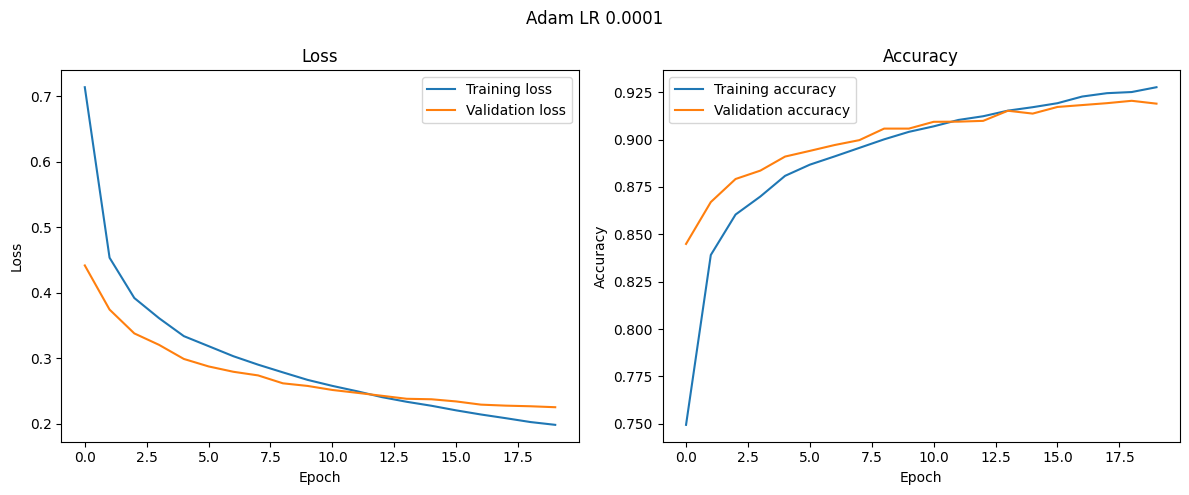

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8307 - loss: 0.4710 - val_accuracy: 0.8841 - val_loss: 0.3077
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8865 - loss: 0.3110 - val_accuracy: 0.8909 - val_loss: 0.2917
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9040 - loss: 0.2607 - val_accuracy: 0.9123 - val_loss: 0.2433
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9145 - loss: 0.2290 - val_accuracy: 0.9072 - val_loss: 0.2611
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9239 - loss: 0.2030 - val_accuracy: 0.9158 - val_loss: 0.2405
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9319 - loss: 0.1822 - val_accuracy: 0.9172 - val_loss: 0.2368
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9390 - loss: 0.1617 - val_accuracy: 0.9231 - val_loss: 0.2344
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9448 - loss: 0.1458 - 

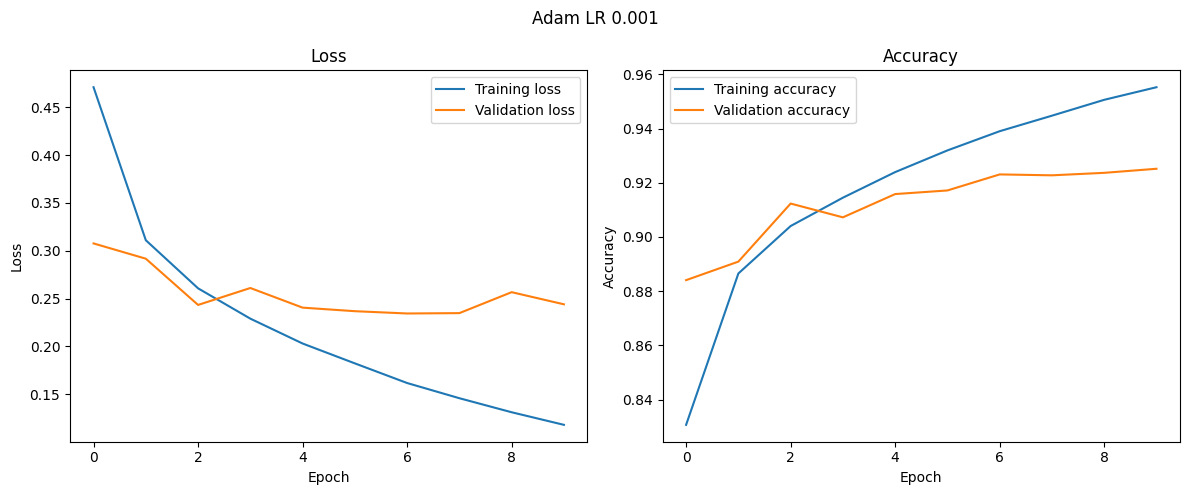

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8239 - loss: 0.4866 - val_accuracy: 0.8551 - val_loss: 0.3739
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8569 - loss: 0.3871 - val_accuracy: 0.8603 - val_loss: 0.3722
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8660 - loss: 0.3626 - val_accuracy: 0.8742 - val_loss: 0.3391
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8698 - loss: 0.3547 - val_accuracy: 0.8810 - val_loss: 0.3323
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8741 - loss: 0.3444 - val_accuracy: 0.8842 - val_loss: 0.3243
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8751 - loss: 0.3402 - val_accuracy: 0.8888 - val_loss: 0.3212
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8751 - loss: 0.3362 - val_accuracy: 0.8833 - val_loss: 0.3308
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8797 - loss: 0.3304 - 

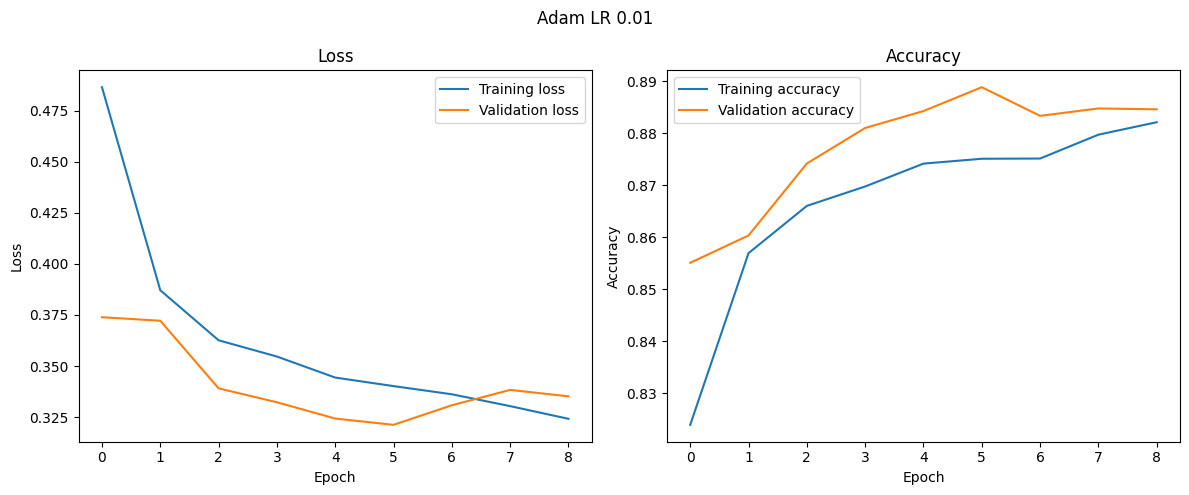

               name  train_accuracy  train_loss  validation_accuracy  validation_loss  epochs_trained  learning_rate  training_time
          Basmodell        0.943750    0.157032             0.908417         0.274462               7         0.0010      22.342468
  Förbättrad modell        0.952625    0.127941             0.916167         0.267856               7         0.0010      31.891955
Förbättrad modell 2        0.955250    0.117969             0.925167         0.244005              10         0.0010      48.816590
      SGD LR 0.0001        0.660563    0.914238             0.712000         0.815127              20         0.0001      88.854151
       SGD LR 0.001        0.835479    0.458895             0.842083         0.437605              20         0.0010      88.781878
        SGD LR 0.01        0.900667    0.271908             0.898333         0.282039              20         0.0100      88.964514
  RMSprop LR 0.0001        0.909792    0.253348             0.906417        

In [21]:
# Experiment med Adam och olika inlärningshastigheter
model_adam_low, h_adam_low, r_adam_low = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="Adam LR 0.0001", optimizer="adam", learning_rate=0.0001)
model_adam, h_adam, r_adam = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="Adam LR 0.001", optimizer="adam", learning_rate=0.001)
model_adam_high, h_adam_high, r_adam_high = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="Adam LR 0.01", optimizer="adam", learning_rate=0.01)
results.extend([r_adam_low, r_adam, r_adam_high])

print(pd.DataFrame(results).to_string(index=False))

### Analys av Adam-experimentet

Adam med learning rate 0.0001 gav de mest stabila kurvorna och ett litet gap mellan tränings- och valideringsdata, men tränade långsammare. 

Modellen tränades under samtliga 20 epoker, vilket tyder på att den fortfarande förbättrades när träningen avslutades. 

Learning rate 0.001 gav högst valideringsaccuracy, men kurvorna visar ett större gap mellan träning och validering. Det tyder på viss överanpassning, även om modellen presterar bra. 

Vid learning rate 0.01 blev resultatet sämgre och valideringsloss förbättrades inte lika tydligt, vilket indikerar att inlärningshastigheten var för hög. 

Sammanfattningsvis gav Adam 0.001 bäst mätvärden, men Adam 0.0001 gav den mest stabila träningen. 

In [ ]:
# Skapar en DataFrame för att på tydligt vis presentera resultatet från samtliga experiment
display(pd.DataFrame(results)
    .sort_values("validation_accuracy", ascending=False)
    .style.format({
    "train_accuracy":      "{:.4f}",
    "train_loss":          "{:.4f}",
    "validation_accuracy": "{:.4f}",
    "validation_loss":     "{:.4f}",
    "epochs_trained":      "{:.0f}",
    "training_time":       "{:.1f}s"
}).highlight_max(subset=["validation_accuracy"], color="darkgreen")
  .highlight_min(subset=["validation_loss"], color="darkblue")
  .set_caption("Sammanfattning av alla experiment")
  .set_table_styles([{"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold")]}]))

,name,train_accuracy,train_loss,validation_accuracy,validation_loss,epochs_trained,learning_rate,training_time
2,Förbättrad modell 2,0.9553,0.1180,0.9252,0.2440,10,0.001000,48.8s
10,Adam LR 0.001,0.9553,0.1180,0.9252,0.2440,10,0.001000,48.5s
9,Adam LR 0.0001,0.9250,0.2025,0.9204,0.2266,20,0.000100,94.4s
1,Förbättrad modell,0.9526,0.1279,0.9162,0.2679,7,0.001000,31.9s
7,RMSprop LR 0.001,0.9307,0.1993,0.9146,0.2694,9,0.001000,38.9s
0,Basmodell,0.9438,0.1570,0.9084,0.2745,7,0.001000,22.3s
6,RMSprop LR 0.0001,0.9098,0.2533,0.9064,0.2666,16,0.000100,70.1s
5,SGD LR 0.01,0.9007,0.2719,0.8983,0.2820,20,0.010000,89.0s
11,Adam LR 0.01,0.8751,0.3402,0.8888,0.3212,9,0.010000,44.8s
8,RMSprop LR 0.01,0.8470,0.4441,0.8644,0.3799,5,0.010000,21.3s


Adam med learning rate 0.001 valdes som slutmodell eftersom den uppnådde högst valideringsaccuracy av samtliga experiment. 

Samtidigt visade Adam 0.0001 stabilare träningskurvor, lägre valideringsloss och mindre skillnad mellan tränings- och valideringsdata vilket tyder på bättre generalisering. 

Eftersom Adam 0.0001 fortfarande förbättrades efter 20 epoker hade modellen möjligtvis kunnat prestera ännu bättre med längre träningstid. 

Trots detta valdes Adam 0.001 eftersom den gav bäst accuracy inom de givna träningsförutsättningarna. 

In [23]:
# Sparar bästa modellen
best_model = model_adam
best_model.save("best_model.keras")

In [ ]:
# Testar bästa modellen på testdatan
best_model = keras.models.load_model("best_model.keras")

test_loss, test_accuracy = best_model.evaluate(X_test_norm, y_test, verbose=0)

In [ ]:
# Presenterar testresultatet i en DataFrame
test_results = pd.DataFrame([{
    "Modell": "Adam LR 0.001",
    "Test accuracy": f"{test_accuracy:.2%}",
    "Test loss": round(test_loss, 4)
}])

test_results

,Modell,Test accuracy,Test loss
0,Adam LR 0.001,91.52%,0.2618


Den valda modellen, Adam med inlärningshastighet 0.001, uppnådde en testaccuracy på 91.52% och en test loss på 0.2618.

Resultatet ligger nära valideringsresultatet vilket indikerar att modellen generaliserar relativt väl till ny data.

## 7 Sammanfattning och slutsatser för fokusområde optimerare och inlärningshastighet

Adam:   
Adam med låg inlärningshastighet 0,0001, har högst accuracy på valideringsdata och tränings- och valideringskurvorna följer varandra väl. Modellen generaliserar bäst av de tre men är den som använder flest epoker och tar längst tid. Adam med hög inlärningshastighet har instabila kutvor och ser ut att hoppa över bra minima. Adam med mellanhastigheten som är en vanlig standard börjar överanpassa vid epok 3 men tar mindre än halva tiden än den med låg inlärningshastighet och kan vara en bra kompromiss.

SGD:   
Med låg inlärningshastighet når SGD inte upp i så hög accuracy på valideringsdatan. Kurvorna visar att modellen inte har lärt sig klart. Med högre inlärningshastighet hinner SGD-modellerna lära sig mer och accuracy på valideringsdatan ökar men ligger fortfarande bland de lägre och under basmodellens. 

RMSprop:    
RMSprop visar ett liknande resultat som Adam där tränings- och valideringskurvorna följer varandra väl i den lägsta inlärningshastiheten medan bästa accuracy på valideringsdatan får i modellen med inlärningshastigheten 0,001. 

**Slutsats**  
SGD är den enklaste optimeraren som bara tar steg baserat på aktuell gradient men den tar inte hänsyn till tidigare steg och blir därför långsammre än de övriga. RMSprop kan anpassa steglängden utifrån tidigare gradienter vilket gör den snabbare. Adam kan också anpassa steglängden men den kan dessutom minnas i vilken riktning stegen tagits och det gör den snabbare att konvergera än SGD och RMSprop.  

Valet av inlärningshastighet påverkar optimerarna olika. SGD är känsligast eftersom den saknar adaptiv anpassning och en för låg inlärningshastighet gör att modellen inte hinner lära sig tillräckligt medan en högre krävs för att nå acceptabel accuracy. RMSprop och Adam är mer förlåtande tack vare sin adaptiva steglängd, men en för hög inlärningshastighet ger instabila kurvor för båda. Generellt gäller att lägre inlärningshastighet ger jämnare kurvor och bättre generalisering men kräver fler epoker, medan högre inlärningshastighet konvergerar snabbare men riskerar att hoppa över bra minima.

**Begränsningar**

- Datasetets enkelhet och omfattning: Fashion MNIST består av väldigt små och helt gråskaliga bilder med centrerade motiv och ren bakgrund. Detta innebär att modellen inte har prövats på den komplexitet (olika vinklar, belysning, skiftande bakgrunder och färger) som finns i verkliga produktbilder
- Undersökningen har fokuserat på tre specifika optimerare (SGD, RMSprop och Adam) samt ett begränsat antal förutbestämda inlärningshastigheter. Andra kritiska hyperparametrar såsom batch size eller specifika inställningar för momentum och decay har hållits konstanta.
- Modellerna har tränats under begränsat antal epoker. Det gör att långsammare optimerare (som SGD) eventuellt inte har hunnit konvergera helt och nå sin fulla potential.
- Fokus har legat på att jämföra optimerare i en och samma grundarkitektur (vilken inkluderar ett dropout-lager). Andra avancerade tekniker för att motverka överanpassning eller snabba på träningen, såsom Batch normalization eller L1/L2-regularisering har inte inkluderats i detta arbete

**Nästa steg**

- Automatiserad hyperparametertuning: 
    - Implementera Keras Tuner (eller verktyg som Optuna/GridSearchCV) för att systematiskt och automatiskt söka igenom kombinationer av inlärningshastighet, optimerare, batchstorlek och antal lager för att hitta den absolut bästa modellen.
- Arkitekturutveckling och regularisering:
    - Experimentera med djupare och mer avancerade faltningsnätverk (CNN).
    - Introducera fler Dropout-lager och Batch Normalization för att stabilisera träningen, minska risken för overfitting och se hur de olika optimerarna reagerar på en mer komplex nätverksstruktur.
- Data Augumentation:
    - Applicera slumpmässiga transformationer på träningsdatat (t.ex. rotation, zoom, horisontell spegling och skiftningar). Detta ökar variationen i datat och tvingar modellen att lära sig mer generella mönster istället för att memorera bilderna. 
- Skala upp till mer komplexa dataset:
    - Utvärdera de bästa konfigurationerna på mer utmanande dataset, till exempel CIFAR-10 (som innehåller färgbilder) eller ett eget insamlat dataset med verkliga, högupplösta kläd- eller produktbilder. Det testar modellens verkliga generaliseringsförmåga.
- Dynamisk learning rate:
    - Implementera callbacks som ReduceLROnPlateau (för att sänka inlärningshastigheten dynamiskt under träningens gång)
